# Gaussian beams

So far every `Beam` was an infinite plane wave. Real lattices are made of focused laser beams, whose finite size adds a harmonic confinement and an inhomogeneous lattice depth, and whose wavefront curvature and Gouy phase slowly distort the lattice away from the focus. A `Beam` can carry a lateral **profile**, which turns its field into
$$\mathbf{E}(\mathbf{r}) = \mathcal{E}\,\mathbf{u}\; u(\mathbf{r})\, e^{i\mathbf{k}\cdot\mathbf{r}}$$
where $u$ is a complex scalar envelope that varies slowly on the scale of the wavelength. The polarization stays transverse, which is the paraxial approximation. The envelope is written in the beam's own frame, centred on its focus $\mathbf{r}_0$: $s = (\mathbf{r}-\mathbf{r}_0)\cdot\mathbf{e}_L$ along the propagation direction, and $t_1$, $t_2$ along the TE and TM unit vectors of the beam.

For a `GaussianProfile`, with the $e^{+i\mathbf{k}\cdot\mathbf{r}}$ convention of the package,
$$u = \prod_{a = 1,2} \frac{1}{\sqrt{1 + i s / z_{R,a}}} \exp\left(-\frac{t_a^2}{w_a^2\,(1 + i s/z_{R,a})}\right), \qquad z_{R,a} = \frac{k_L w_a^2}{2}$$
which contains the beam width $w(s) = w_0\sqrt{1+(s/z_R)^2}$, the wavefront curvature and the Gouy phase $-\arctan(s/z_R)$. By default $u = 1$ at the focus, so the beam's `amplitude` keeps its meaning: the peak field.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from bloch_schrodinger.potential import create_parameter

from optilat import Beam, GaussianProfile, OptiLat, intensity, stark_potential

lamb = 1.0  # Laser wavelength, the unit of length here
k_l = 2 * np.pi / lamb


def axis(name, start, stop, n):
    return xr.DataArray(
        np.linspace(start, stop, n), coords={name: np.linspace(start, stop, n)}
    )

## A single Gaussian beam

A deliberately tight waist, $w_0 = 2\lambda$, makes the Rayleigh range $z_R = \pi w_0^2/\lambda \approx 12.6\,\lambda$ small enough to see the beam spread over the plot. The left panel shows the intensity in the $xz$ plane, with the $1/e^2$ radius $w(z)$ on top. The right panel shows the phase of the envelope on axis: the Gouy phase.

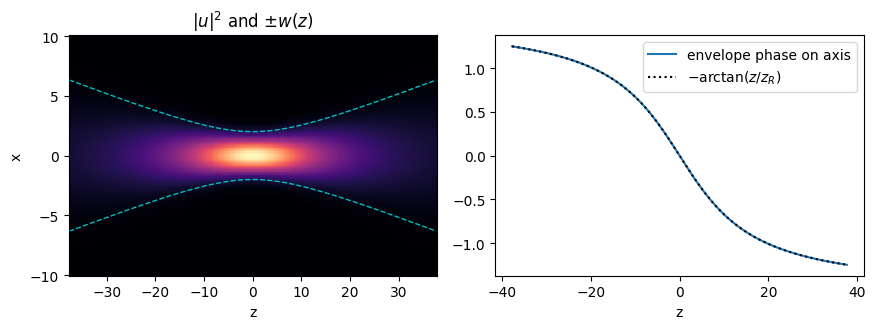

In [13]:
w0 = 2.0
profile = GaussianProfile(waist=w0)
beam = Beam(wavelength=lamb, direction=[0, 0, 1], profile=profile)

zR = profile.rayleigh_range(k_l)[0]
x = axis("x", -10, 10, 201)
z = axis("z", -3 * zR, 3 * zR, 301)

u = beam.envelope(x=x, y=0, z=z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
(abs(u) ** 2).plot(x="z", y="x", ax=ax1, cmap="magma", add_colorbar=False)
w_TE, _ = profile.width(z, k_l)
for sign in (1, -1):
    ax1.plot(z, sign * w_TE, "c--", lw=1)
ax1.set_title(r"$|u|^2$ and $\pm w(z)$")

ax2.plot(z, np.unwrap(np.angle(u.sel(x=0))), label="envelope phase on axis")
ax2.plot(z, -np.arctan(z / zR), "k:", label=r"$-\arctan(z/z_R)$")
ax2.set_xlabel("z")
ax2.legend()
plt.tight_layout()
plt.show()

The focus does not have to be at the origin, and the beam can point in any direction: the envelope is evaluated in the beam frame, so `compute_fields` handles it like any plane wave.

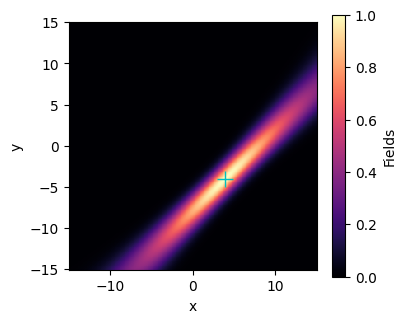

In [19]:
tilted = Beam(
    wavelength=lamb,
    direction=[1, 1, 0],
    profile=GaussianProfile(waist=2, focus=[4, -4, 0]),
)
lat = OptiLat()
lat.add_beam(tilted)

x, y = axis("x", -15, 15, 301), axis("y", -15, 15, 301)
I = intensity(lat.compute_fields(x=x, y=y, z=0))

fig, ax = plt.subplots(figsize=(4, 3.4))
I.plot(x="x", y="y", ax=ax, cmap="magma")
ax.plot(4, -4, "c+", ms=12)
ax.set_aspect("equal")
plt.show()

## A finite-size 1D lattice

Two counter-propagating beams with the same focus and the same waist make a 1D lattice whose depth follows the transverse Gaussian. With unit amplitudes and the scalar polarizability $\alpha_s$, the potential at an antinode (here $x = \lambda/4$, since the TE vectors of counter-propagating beams are opposite) is $V = -\alpha_s e^{-2\rho^2/w_0^2}$ near the focus. Each lattice site then sits in a transverse harmonic trap of curvature $\partial_\rho^2 V = 4\alpha_s/w_0^2$, which is what sets the transverse trapping frequency of a real 1D lattice.

curvature: numerical 0.9369, analytic 4 alpha_s / w0^2 = 1.0000


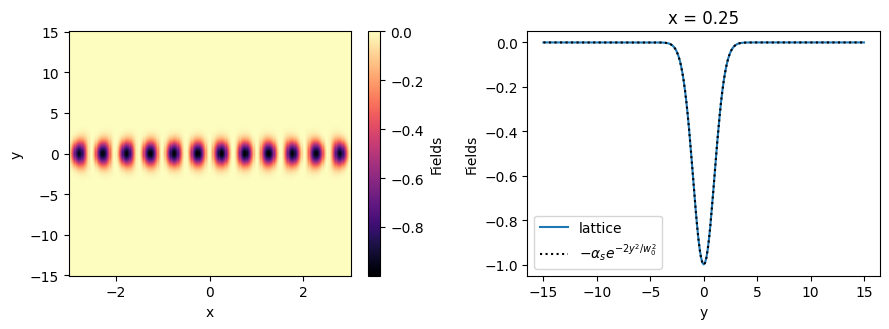

In [27]:
w0 = 2
alpha_s = 1.0
lattice = OptiLat()
lattice.add_beam(
    [
        Beam(wavelength=lamb, direction=[1, 0, 0], profile=GaussianProfile(w0)),
        Beam(wavelength=lamb, direction=[-1, 0, 0], profile=GaussianProfile(w0)),
    ],
    0,
)

x, y = axis("x", -3, 3, 241), axis("y", -15, 15, 241)
V = stark_potential(lattice.compute_fields(x=x, y=y, z=0), alpha_s=alpha_s)

# The TE vectors of counter-propagating beams are opposite, so the origin is a node:
# the transverse cut goes through the antinode at x = lambda/4
cut = V.sel(x=lamb / 4, method="nearest")
small = cut.sel(y=slice(-0.5, 0.5))
curvature = 2 * np.polyfit(small.y, small, 2)[0]
print(
    f"curvature: numerical {curvature:.4f}, analytic 4 alpha_s / w0^2 = {4 * alpha_s / w0**2:.4f}"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
V.plot(x="x", y="y", ax=ax1, cmap="magma")
cut.plot(ax=ax2, label="lattice")
ax2.plot(
    y, -alpha_s * np.exp(-2 * y**2 / w0**2), "k:", label=r"$-\alpha_s e^{-2y^2/w_0^2}$"
)
ax2.legend()
plt.tight_layout()
plt.show()

Away from the focus, the two beams pick up opposite Gouy phases. Their interference pattern then slips by $\arctan(s/z_R)/k_L$ relative to a perfect standing wave, a quarter of a lattice period over the whole Rayleigh range. With `diffraction=False` the profile keeps only the transverse Gaussian $e^{-t_1^2/w_1^2 - t_2^2/w_2^2}$. That model is real and cheaper, and it is accurate as long as the region of interest stays well within the Rayleigh range.

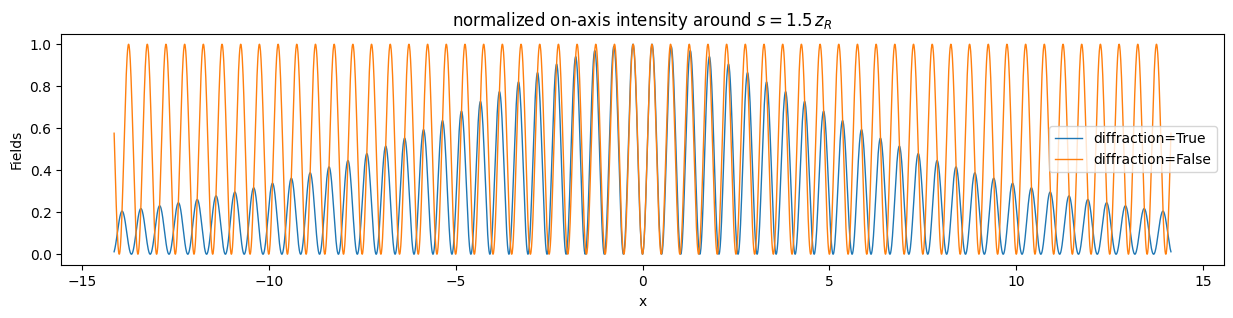

In [41]:
w0 = 1.5
zR = k_l * w0**2 / 2
x = axis("x", -2 * zR, 2 * zR, 4001)


def on_axis(diffraction):
    lat = OptiLat()
    lat.add_beam(
        [
            Beam(
                wavelength=lamb,
                direction=[d, 0, 0],
                profile=GaussianProfile(w0, diffraction=diffraction),
            )
            for d in (1, -1)
        ],
        0,
    )
    return intensity(lat.compute_fields(x=x, y=0, z=0))


fig, ax = plt.subplots(figsize=(15, 3))
for diffraction in (True, False):
    I = on_axis(diffraction)
    (I / I.max()).plot(ax=ax, label=f"diffraction={diffraction}", linewidth = 1)
ax.set_title(r"normalized on-axis intensity around $s = 1.5\,z_R$")
ax.legend()
plt.show()

## Elliptical beams

`waist` also accepts a pair $[w_{TE}, w_{TM}]$, the waists along the beam's TE and TM unit vectors. For beams in the $xy$ plane, TE lies in that plane and TM is (almost) vertical. A small $w_{TM}$ therefore makes flat beams, the light-sheet geometry used to confine a 2D lattice vertically. Below is the honeycomb lattice of the other notebooks, built from elliptical beams with $w_{TE} = 15$ and $w_{TM} = 3$.

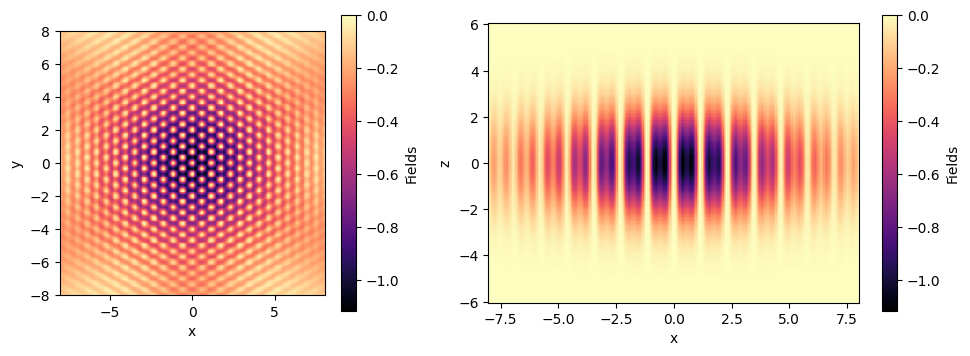

In [47]:
angles = [np.pi / 2 + 2 * np.pi / 3 * i for i in range(3)]
honeycomb = OptiLat()
honeycomb.add_beam(
    [
        Beam(
            wavelength=lamb,
            direction=[np.cos(a), np.sin(a), 0],
            polar=[1, 0],
            profile=GaussianProfile([5.0, 3.0]),
        )
        for a in angles
    ],
    0,
)

x, y, z = axis("x", -8, 8, 301), axis("y", -8, 8, 301), axis("z", -6, 6, 121)
V_xy = stark_potential(honeycomb.compute_fields(x=x, y=y, z=0))
V_xz = stark_potential(honeycomb.compute_fields(x=x, y=0, z=z))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), width_ratios=[1, 1.4])
V_xy.plot(x="x", y="y", ax=ax1, cmap="magma")
ax1.set_aspect("equal")
V_xz.plot(x="x", y="z", ax=ax2, cmap="magma")
ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## Waists as parameters, and power normalization

As with every other input of a `Beam`, the waist can be a parameter dimension. By default the beam's amplitude is its peak field, so a tighter waist gives the same peak intensity on a smaller area. With `power=P`, the envelope is scaled by $\sqrt{2P/(\pi w_{TE} w_{TM})}$ instead, so that $\int |\mathbf{E}|^2\,dA = P$ over any transverse plane, in the arbitrary units of the package. A tighter waist then concentrates the same power and makes a deeper potential. When `power` is given, the beam's `amplitude` only multiplies this normalization, so keep it at 1.

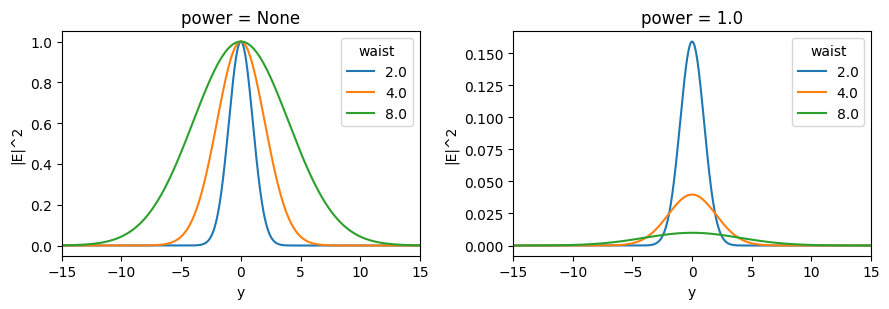

power: [1. 1. 1.]


In [48]:
waist = create_parameter("waist", np.array([2.0, 4.0, 8.0]))
y = axis("y", -30, 30, 1201)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharex=True)
for ax, power in zip(axes, (None, 1.0)):
    lat = OptiLat()
    lat.add_beam(
        Beam(
            wavelength=lamb,
            direction=[1, 0, 0],
            profile=GaussianProfile(waist, power=power),
        )
    )
    I = intensity(lat.compute_fields(x=0, y=y, z=0)).rename("|E|^2")
    I.plot(hue="waist", ax=ax)
    ax.set_title(f"power = {power}")
    ax.set_xlim(-15, 15)
plt.tight_layout()
plt.show()

# The power through the y axis of a round beam, 2D-integrated using its symmetry: int |E|^2 dA = int |E|^2 dy * int exp(-2 z^2/w^2) dz
print("power:", (I.integrate("y") * waist * np.sqrt(np.pi / 2)).values)

## Time-dependent lattices

The time-dependent machinery of the `dynamics` module works unchanged. The envelopes are static, so a driven lattice of Gaussian beams still splits exactly into static gratings $G_{jl}(\mathbf{r}) = (\mathbf{A}_j\cdot\mathbf{A}_l^*)\,u_j(\mathbf{r})u_l^*(\mathbf{r})\,e^{i(\mathbf{k}_j-\mathbf{k}_l)\cdot\mathbf{r}}$ times pure time functions. Below, the honeycomb of elliptical beams is loaded with a depth ramp and added to a `PotentialT`. The `add_to_analytic` route works just the same.

9 gratings


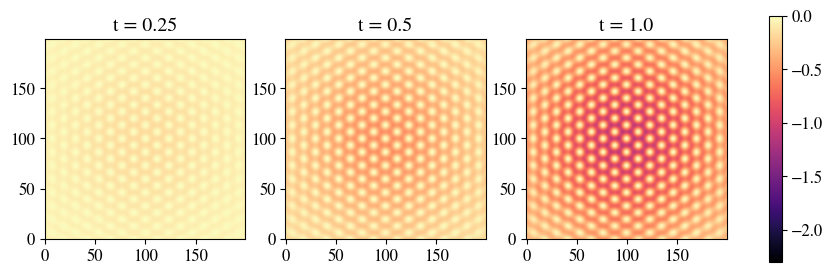

In [49]:
from BECs.potentialT import PotentialT

from optilat import BeamDrive, LatticeDrive, add_to_potentialT

box = PotentialT(
    [[10, 0], [0, 10]], resolution=(200, 200), v0=0
)  # the grid must resolve the lattice

drive = LatticeDrive(honeycomb)
drive[:] = BeamDrive.ramp(vi=0.0, vf=1.0, ti=0.0, tf=1.0, on="depth")
expansion = add_to_potentialT(box, honeycomb, drive, alpha_s=1.0)
print(f"{len(expansion.gratings)} gratings")

Vt = box.make_Vt({})
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, t in zip(axes, (0.25, 0.5, 1.0)):
    im = ax.imshow(np.asarray(Vt(t)).T, origin="lower", cmap="magma", vmin=-2.3, vmax=0)
    ax.set_title(f"t = {t}")
fig.colorbar(im, ax=axes)
plt.show()